In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/sample_submission.csv
/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/train.csv
/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/test.csv")
df_sample_submission = pd.read_csv("/kaggle/input/competitions/binary-classification-with-a-bank-dataset-clone/sample_submission.csv")

# EDA

In [4]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [5]:
df.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0
749999,749999,42,technician,married,secondary,no,1559,no,no,cellular,4,aug,143,1,1,7,failure,0


In [6]:
df_sample_submission.head()

,id,y
0,750000,0.5
1,750001,0.5
2,750002,0.5
3,750003,0.5
4,750004,0.5


In [7]:
df_test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [9]:
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

<Axes: ylabel='count'>

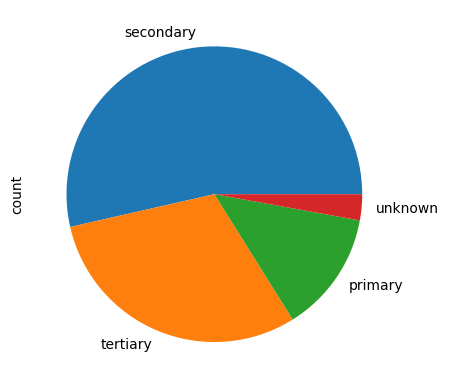

In [10]:
df["education"].value_counts().plot.pie()

<Axes: ylabel='count'>

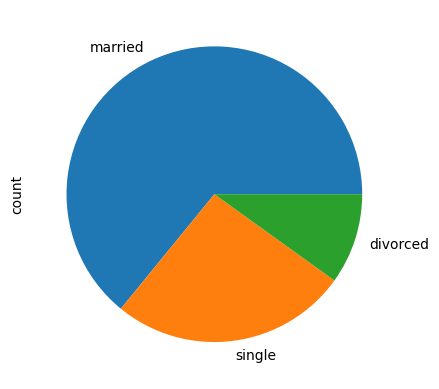

In [11]:
df["marital"].value_counts().plot.pie()

In [12]:
df = df.drop(columns=["id","poutcome"])

# AI Training

In [13]:
x=df.drop('y', axis=1)
y=df[['y']]

In [14]:
x=pd.get_dummies(x, drop_first=True)

In [15]:
x

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,42,7,25,117,3,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,38,514,18,185,1,-1,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,36,602,14,111,2,-1,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,27,34,28,10,2,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,26,889,3,902,1,-1,0,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,29,1282,4,1006,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
749996,69,631,19,87,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
749997,50,217,17,113,1,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
749998,32,-274,26,108,6,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
from sklearn.preprocessing import normalize, scale

In [17]:
x=normalize(x)

In [18]:
x_train, x_test, y_train,y_test=train_test_split(x,y, test_size=0.15,random_state=42)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-04-15 20:15:01.546230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776284101.685833      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776284101.727923      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776284102.072971      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284102.073001      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284102.073004      16 computation_placer.cc:177] computation placer alr

In [20]:
model=Sequential()
model.add(Dense(80,activation='relu'))
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(20,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

2026-04-15 20:15:17.397371: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
early_stop=EarlyStopping(monitor='val_loss',patience=20)

In [24]:
history=model.fit(x_train,y_train, epochs=100,callbacks=[early_stop], batch_size=64, validation_data=(x_test,y_test),verbose=1)

Epoch 1/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8934 - loss: 0.2404 - val_accuracy: 0.9064 - val_loss: 0.1957
Epoch 2/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9091 - loss: 0.1959 - val_accuracy: 0.9086 - val_loss: 0.1912
Epoch 3/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9115 - loss: 0.1909 - val_accuracy: 0.9131 - val_loss: 0.1860
Epoch 4/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9141 - loss: 0.1866 - val_accuracy: 0.9184 - val_loss: 0.1829
Epoch 5/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9155 - loss: 0.1847 - val_accuracy: 0.9157 - val_loss: 0.1827
Epoch 6/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9165 - loss: 0.1826 - val_accuracy: 0.9174 - val_loss: 0.1792
Epoch 7/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9179 - loss: 0.1816 - val_accuracy: 0.9163 - val_loss: 0.1825
Epoch 8/100
9961/9961 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9181 -

In [25]:
loss, accurancy=model.evaluate(x,y)

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - accuracy: 0.9251 - loss: 0.1660


In [26]:
accurancy

0.9252399802207947

In [27]:
model.save('bank_model.h5')

In [28]:
model.save('bank_model.keras')